In [1]:
import numpy as np
import bayesflow as bf
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def theta_step(batch_shape=1, mu=0.0, sigma=1.0,alpha=2, beta=1.0):
    mu_val = np.random.normal(loc=mu, scale=sigma)
    mu_sample = np.float32(mu_val)
    sigma_val = 1/np.random.gamma(shape=alpha, scale=1/beta)
    sigma_sample = np.float32(sigma_val)
    
    theta = np.array([mu_sample,sigma_sample], dtype=np.float32)
    return {"theta": theta}


def forward_step(theta, **kwargs):
    mu = theta[0]
    sigma2=theta[1]
    obs = np.random.normal(loc=mu, scale=np.sqrt(sigma2), size=(100, 1)).astype(np.float32)
    
    return {"x": obs}


In [3]:
simulator = bf.make_simulator(
    [theta_step, forward_step],
    expand_outputs=False
)
        
def flatten_inference_conditions(data, **kwargs):
    if "inference_conditions" in data:
        conditions = data["inference_conditions"]
        data["inference_conditions"] = conditions.reshape(conditions.shape[0], -1)
    return data



adapter = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype("float64", "float32") 
    .rename("theta", "inference_variables")
    .rename("x", "inference_conditions")
    .append(flatten_inference_conditions)
)

In [4]:
num_training_batches   = 500
num_batch_size            = 32
num_epochs                = 15

In [5]:
affine_flow = bf.networks.CouplingFlow(subnet="mlp")

affine_flow_workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=affine_flow,
)

In [6]:
history = affine_flow_workflow.fit_online(
    epochs=num_epochs,
    number_batches=num_training_batches,
    batch_size=num_batch_size,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 9.7921 - loss/inference_loss: 9.7921  
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.9804 - loss/inference_loss: 0.9804
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: -0.1905 - loss/inference_loss: -0.1905
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: -0.7971 - loss/inference_loss: -0.7971
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: -1.2263 - loss/inference_loss: -1.2263
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: -1.2855 - loss/inference_loss: -1.2855
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: -1.3433 - loss/inference_loss: -1.3433
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: -1.4809 - loss/inference_loss: -1.4809
Epoch 9/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: -1.5162 - loss/inference_loss: -1.5162
Epoch 10/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: -1.6440 - loss/inference_loss: -1.6440
E

In [47]:
test_size = 1 
test_batch = simulator.sample((test_size,))

theta_true = test_batch["theta"]
x_test = test_batch["x"] 


In [48]:
# Get types and shapes of x_test and theta_true
x_test_type = x_test.dtype
x_test_shape = x_test.shape

theta_true_type = theta_true.dtype
theta_true_shape = theta_true.shape

x_test_type, x_test_shape, theta_true_type, theta_true_shape


(dtype('float32'), (1, 100, 1), dtype('float32'), (1, 2))

In [ ]:

# Sample from the posterior
num_samples = 300

posterior_samples_affine= affine_flow_workflow.approximator.sample(
    conditions={"inference_conditions": x_test}, 
    num_samples=num_samples
)["theta"]

In [39]:
n_obs = 100  # Number of samples
true_miu = 0.4   # True mean
true_sigma = 0.7  # True standard deviation
obs_data= np.random.normal(loc=true_miu, scale=true_sigma, size=(n_obs, 1)).astype(np.float32)

In [51]:
n_obs = 100
true_miu = 0.4   # True mean
true_sigma = 0.7  # True standard deviation

# Generate observations
obs_data = np.random.normal(loc=true_miu, scale=true_sigma, size=(100, 1)).astype(np.float32)
x_test = obs_data.reshape(1, 100, 1)  # Reshape to (1, 100, 1)

# Theta true
theta_true = np.array([[true_miu, true_sigma]], dtype=np.float32)


In [52]:
# Get types and shapes of x_test and theta_true
x_test_type = x_test.dtype
x_test_shape = x_test.shape

theta_true_type = theta_true.dtype
theta_true_shape = theta_true.shape

x_test_type, x_test_shape, theta_true_type, theta_true_shape


(dtype('float32'), (1, 100, 1), dtype('float32'), (1, 2))

In [ ]:
# Sample from the posterior
num_samples = 300

posterior_samples_affine= affine_flow_workflow.approximator.sample(
    conditions={"inference_conditions": x_test}, 
    num_samples=num_samples
)["theta"]

In [54]:
import numpy as np

def bayes_estimator(data, mu_0=0, sigma_0=1, kappa_0=1, alpha_0=2, beta_0=1, n_samples=1000):
    """
    Conjugate Normal-Inverse-Gamma posterior update for data ~ N(mu, sigma^2).
    Prior:   mu|sigma^2 ~ N(mu_0, sigma^2/kappa_0),
             sigma^2    ~ InvGamma(alpha_0, beta_0).

    Returns samples from the joint posterior p(mu, sigma^2 | data).
    """
    # Ensure data is a numpy array
    data = np.array(data).squeeze()
    n = len(data)
    sample_mean = np.mean(data)
    sample_var_sum = np.sum((data - sample_mean)**2)  # S

    # Posterior parameters
    kappa_n = kappa_0 + n
    alpha_n = alpha_0 + 0.5 * n
    beta_n = beta_0 + 0.5 * sample_var_sum + 0.5 * (kappa_0 * n / kappa_n) * (sample_mean - mu_0)**2
    mu_n = (kappa_0 * mu_0 + n * sample_mean) / kappa_n

    # 1) Sample sigma^2 from Inverse-Gamma(alpha_n, beta_n)
    # Inverse-Gamma is the reciprocal of Gamma
    sigma2_samples = 1 / np.random.gamma(shape=alpha_n, scale=1 / beta_n, size=n_samples)

    # 2) For each sigma^2 draw, sample mu ~ Normal(mu_n, sigma^2 / kappa_n)
    mu_stddev = np.sqrt(sigma2_samples / kappa_n)
    mu_samples = np.random.normal(loc=mu_n, scale=mu_stddev, size=n_samples)

    return mu_samples, sigma2_samples


In [55]:
reference_posterior_mu, reference_posterior_sigma = bayes_estimator(x_test)

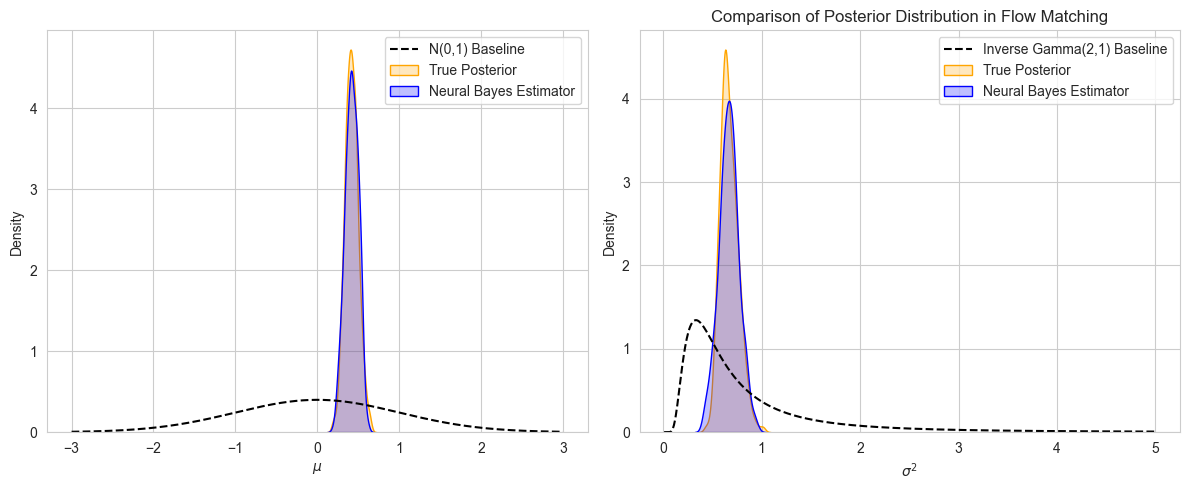

In [ ]:
# Extract samples for mu and sigma^2 (for the first test sample)
mu_samples = posterior_samples_affine[0, :, 0]      # First dimension: mu
sigma2_samples = posterior_samples_affine[0, :, 1]  # Second dimension: sigma^2

mu_true = theta_true[0, 0]         # True value of mu
sigma2_true = theta_true[0, -1]    # True value of sigma^2

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- 1. Posterior distribution of mu ---
# Generate density curve for N(0,1)
x = np.linspace(-3, 3, 1000)  # Set x-axis range
y = stats.norm.pdf(x, loc=0, scale=1)  # Compute probability density of N(0,1)

# Plot N(0,1) curve on the same axis
axes[0].plot(x, y, label="N(0,1) Baseline", color="black", linestyle="--")  
sns.kdeplot(reference_posterior_mu, label="True Posterior", fill=True, color="orange", ax=axes[0])
sns.kdeplot(mu_samples, fill=True, color="blue", label="Neural Bayes Estimator", ax=axes[0])
axes[0].set_title("Comparison of Posterior Distribution in Flow Matching")
axes[0].set_xlabel("$\mu$")
axes[0].set_ylabel("Density")
axes[0].legend()

# --- 2. Posterior distribution of sigma^2 ---
# Generate density curve for Inverse Gamma(2,1)
x = np.linspace(0.01, 5, 1000)  # Inverse Gamma domain is x > 0 to avoid division by zero
y = stats.invgamma.pdf(x, a=2, scale=1)  # α=2, β=1

# Plot Inverse Gamma(2,1) as a baseline
axes[1].plot(x, y, label="Inverse Gamma(2,1) Baseline", color="black", linestyle="--")

sns.kdeplot(reference_posterior_sigma, label="True Posterior", fill=True, color="orange", ax=axes[1])
sns.kdeplot(sigma2_samples, fill=True, color="blue", label="Neural Bayes Estimator", ax=axes[1])
axes[1].set_title("Comparison of Posterior Distribution in Flow Matching")
axes[1].set_xlabel("$\sigma^2$")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
test_size = 100
test_batch_100 = simulator.sample((test_size,))

# Extract theta_true and x_test
theta_true_100 = test_batch_100["theta"]  # [test_size, 48]
x_test_100 = test_batch_100["x"]  # [test_size, 4700]

posterior_samples_affine = affine_flow_workflow.approximator.sample(
    conditions={"inference_conditions": x_test_100},  # Changed to inference_conditions
    num_samples=300
)["theta"]

Text(0, 0.5, 'Estimated')

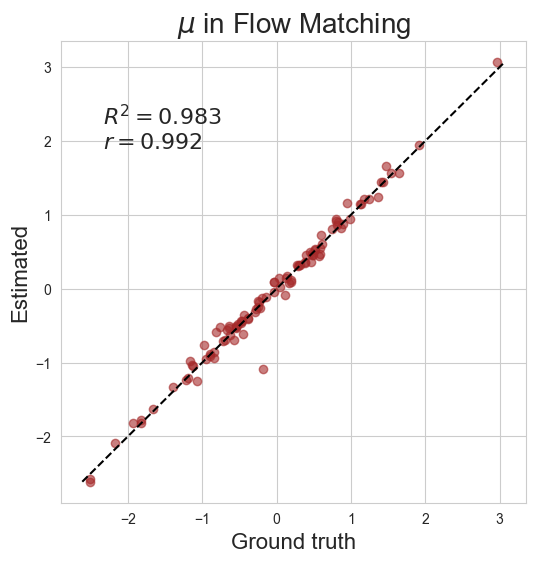

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Compute posterior means => shape (test_size, 48)
posterior_means = posterior_samples_affine.mean(axis=1)

# Select the first dimension for plotting
i = 0

plt.figure(figsize=(6, 6))
plt.scatter(theta_true_100[:, i], posterior_means[:, i], alpha=0.6, color="brown")

# Plot diagonal line
min_val = min(theta_true_100[:, i].min(), posterior_means[:, i].min())
max_val = max(theta_true_100[:, i].max(), posterior_means[:, i].max())
plt.plot([min_val, max_val], [min_val, max_val], "k--")

# Compute correlation coefficient & R²
r = np.corrcoef(theta_true_100[:, i], posterior_means[:, i])[0, 1]
r2 = r2_score(theta_true_100[:, i], posterior_means[:, i])

# Annotate R² and r in the top-left corner
plt.text(min_val + 0.05 * (max_val - min_val), 
         max_val - 0.1 * (max_val - min_val), 
         f'$R^2 = {r2:.3f}$\n$r = {r:.3f}$', 
         fontsize=16, 
         ha='left', 
         va='top')

plt.title(r"$\mu$ in Flow Matching", fontsize=20)
plt.xlabel("Ground truth", fontsize=16)
plt.ylabel("Estimated", fontsize=16)

plt.show()


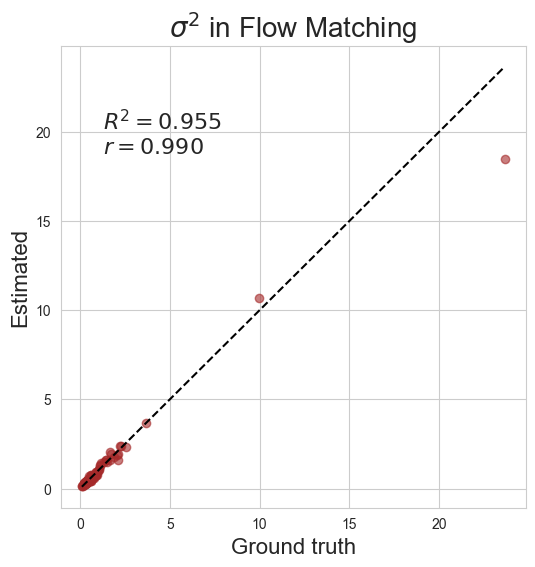

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Compute posterior means => shape (test_size, 48)
posterior_means = posterior_samples_affine.mean(axis=1)

# Select the second dimension for plotting
i = 1

plt.figure(figsize=(6, 6))
plt.scatter(theta_true_100[:, i], posterior_means[:, i], alpha=0.6, color="brown")

# Plot diagonal line
min_val = min(theta_true_100[:, i].min(), posterior_means[:, i].min())
max_val = max(theta_true_100[:, i].max(), posterior_means[:, i].max())
plt.plot([min_val, max_val], [min_val, max_val], "k--")

# Compute correlation coefficient & R²
r = np.corrcoef(theta_true_100[:, i], posterior_means[:, i])[0, 1]
r2 = r2_score(theta_true_100[:, i], posterior_means[:, i])

# Annotate R² and r in the top-left corner
plt.text(min_val + 0.05 * (max_val - min_val), 
         max_val - 0.1 * (max_val - min_val), 
         f'$R^2 = {r2:.3f}$\n$r = {r:.3f}$', 
         fontsize=16, 
         ha='left', 
         va='top')

plt.title(r"$\sigma^2$ in Flow Matching", fontsize=20)
plt.xlabel("Ground truth", fontsize=16)
plt.ylabel("Estimated", fontsize=16)

plt.show()


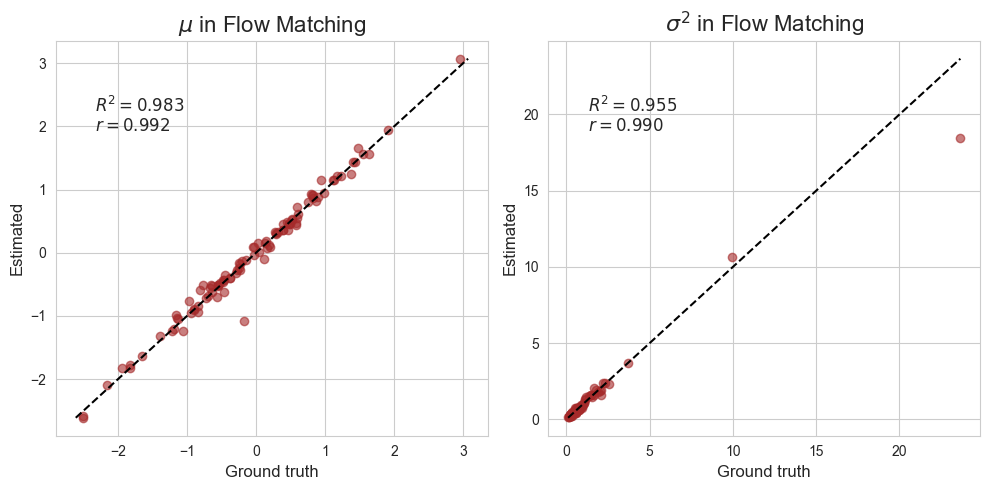

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Compute posterior means => shape (test_size, 48)
posterior_means = posterior_samples_affine.mean(axis=1)

# ======== Create subplots ========
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Arrange two plots horizontally

# ======== i = 0 ========
i = 0
axes[0].scatter(theta_true_100[:, i], posterior_means[:, i], alpha=0.6, color="brown")

# Plot diagonal line
min_val = min(theta_true_100[:, i].min(), posterior_means[:, i].min())
max_val = max(theta_true_100[:, i].max(), posterior_means[:, i].max())
axes[0].plot([min_val, max_val], [min_val, max_val], "k--")

# Compute correlation coefficient & R²
r = np.corrcoef(theta_true_100[:, i], posterior_means[:, i])[0, 1]
r2 = r2_score(theta_true_100[:, i], posterior_means[:, i])
axes[0].text(min_val + 0.05 * (max_val - min_val), 
             max_val - 0.1 * (max_val - min_val), 
             f'$R^2 = {r2:.3f}$\n$r = {r:.3f}$', 
             fontsize=12, 
             ha='left', 
             va='top')

axes[0].set_title(r"$\mu$ in Flow Matching", fontsize=16)
axes[0].set_xlabel("Ground truth", fontsize=12)
axes[0].set_ylabel("Estimated", fontsize=12)


# ======== i = 1 ========
i = 1
axes[1].scatter(theta_true_100[:, i], posterior_means[:, i], alpha=0.6, color="brown")

# Plot diagonal line
min_val = min(theta_true_100[:, i].min(), posterior_means[:, i].min())
max_val = max(theta_true_100[:, i].max(), posterior_means[:, i].max())
axes[1].plot([min_val, max_val], [min_val, max_val], "k--")

# Compute correlation coefficient & R²
r = np.corrcoef(theta_true_100[:, i], posterior_means[:, i])[0, 1]
r2 = r2_score(theta_true_100[:, i], posterior_means[:, i])
axes[1].text(min_val + 0.05 * (max_val - min_val), 
             max_val - 0.1 * (max_val - min_val), 
             f'$R^2 = {r2:.3f}$\n$r = {r:.3f}$', 
             fontsize=12, 
             ha='left', 
             va='top')

axes[1].set_title(r"$\sigma^2$ in Flow Matching", fontsize=16)
axes[1].set_xlabel("Ground truth", fontsize=12)
axes[1].set_ylabel("Estimated", fontsize=12)

# ======== Adjust layout ========
plt.tight_layout()
plt.show()


In [54]:
import bayesflow.diagnostics as diag

(100, 300, 2)

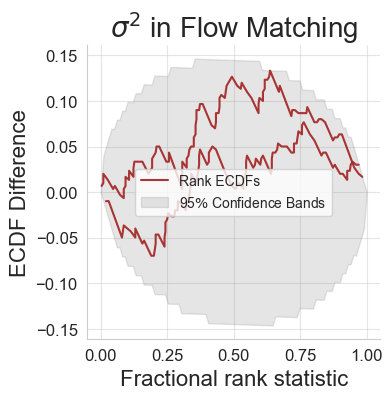

In [ ]:
import matplotlib.pyplot as plt

f = diag.calibration_ecdf(
    targets=posterior_samples_affine,   # Posterior samples, shape (N=100, S=300, D=48)
    references=theta_true_100,          # True parameters, shape (N=100, D=48)
    stacked=True,
    difference=True,
    legend_fontsize=12,
    figsize=(4, 4)                      # Ensure correct parameter name
)

# Change all line colors in the plot to brown
for line in f.axes[0].get_lines():
    line.set_color("brown")  # Modify all lines to brown

# Modify legend colors
legend = f.axes[0].legend()
for line in legend.get_lines():
    line.set_color("brown")  # Modify all legend lines to brown

# Change title to \sigma^2
f.axes[0].set_title(r"$\sigma^2$ in Flow Matching", fontsize=20) 

plt.show()

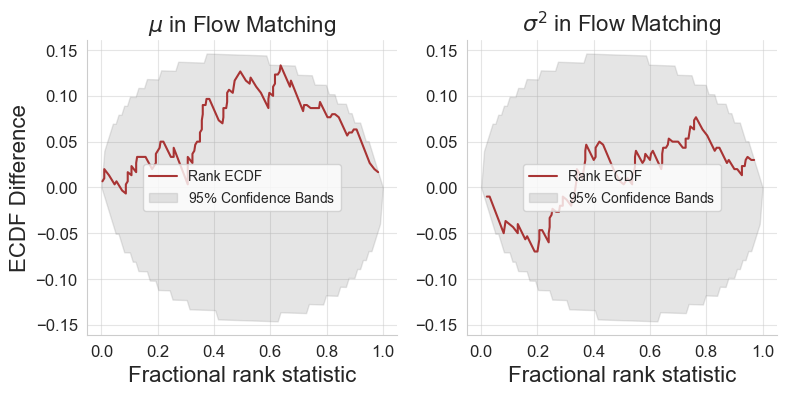

In [ ]:
import matplotlib.pyplot as plt

# ======== Call calibration_ecdf ========
f = diag.calibration_ecdf(
    targets=posterior_samples_affine,   
    references=theta_true_100,          
    stacked=False,
    difference=True,
    legend_fontsize=10,  # Reduce font size slightly
    figsize=(8, 4),      # Adjust figure size (width, height)
    line_width=1.5,      # Reduce line width for better aesthetics
    marker_size=4,       # Reduce marker size to avoid overlap
    font_scale=1.2       # Adjust font scale for better label/title balance
)

# ======== Modify colors and legend ========
# Change all line colors to brown
for ax in f.axes:
    for line in ax.get_lines():
        line.set_color("brown")  # Set line color
    # Modify legend line colors
    legend = ax.legend()
    for line in legend.get_lines():
        line.set_color("brown")

# ======== Modify subplot titles ========
f.axes[0].set_title(r"$\mu$ in Flow Matching", fontsize=16)
f.axes[1].set_title(r"$\sigma^2$ in Flow Matching", fontsize=16)

# ======== Display figure ========
plt.show()


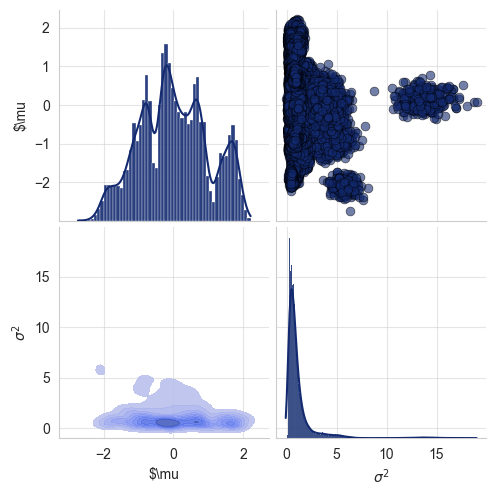

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import bayesflow.diagnostics as diag

# Reshape to (test_size * n_samples, 48)
flattened_samples = posterior_samples_affine.reshape(-1, posterior_samples_affine.shape[-1])

# Extract the last 2 parameters (dimensions)
subset = {
    r"$\mu$": flattened_samples[:, -2],
    r"$\sigma^2$": flattened_samples[:, -1]
}

# Call pairs_samples to plot the Pair Plot
grid = diag.plots.pairs_samples(subset)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import bayesflow.diagnostics as diag

# Extract posterior samples for the first test instance, shape (300, 48)
posterior_first = posterior_samples_affine[0]  

# Extract the last 2 parameters (dimensions)
subset = {
    r"$\mu$": posterior_first[:, -2],
    r"$\sigma^2$": posterior_first[:, -1]
}

# Call pairs_samples to plot the Pair Plot
grid = diag.plots.pairs_samples(subset)

plt.show()
